# 🌗 Contrastive Learning

In the previous notebook, we explored **Self-Supervised Learning (SSL)** using a "pretext task" (predicting image rotation). While effective, designing good pretext tasks is an art form.

Today, we explore a more general and powerful paradigm of SSL: **Contrastive Learning**.

### The Intuition: "Like goes with Like"

The core idea is simple: **Learn a latent space where similar data points (Positive Pairs) are pulled close together, and dissimilar data points (Negative Pairs) are pushed far apart.**

### The SimCLR Framework

Contrastive learning frameworks like **SimCLR** achieve this through **Instance Discrimination**:

1.  **Positive Pair Generation:** Take one image $x$ and apply two different, strong random data augmentations to create two "views," $\tilde{x}_i$ and $\tilde{x}_j$. These two views form the positive pair.
2.  **Negative Pairs:** All other images in the batch are automatically treated as negative examples relative to $x$.



The architecture consists of:
1.  **Data Augmentation Module:** Creates the two views.
2.  **Base Encoder $f(\cdot)$:** Extracts the representation $\mathbf{h}$. (This is the feature extractor we keep).
3.  **Projection Head $g(\cdot)$:** Maps $\mathbf{h}$ to the contrastive space $\mathbf{z}$. (This head is discarded after training).
4.  **Contrastive Loss (NT-Xent):** The objective function.

## 1. Setup and Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Configuration
BATCH_SIZE = 128     # Larger batch sizes are generally better
LEARNING_RATE = 3e-4
TEMPERATURE = 0.5    # A crucial hyperparameter for the loss function
EMBEDDING_DIM = 128  # Dimension of the output of the Projection Head (z)
NUM_EPOCHS = 10       # Kept low for demonstration speed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Component 1: The Data Augmentation Module

We create a custom PyTorch dataset that returns **two highly augmented views** for every input image. This step is critical.

In [4]:
class SimCLRDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

        # Define strong augmentations for 32x32 images (CIFAR-10)
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([
                transforms.ColorJitter(0.4, 0.4, 0.4, 0.1) # Color jitter
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2), # Random grayscale
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # Get the original raw image (before any transforms)
        img, label = self.base_dataset[idx]

        # Apply the SAME transform pipeline TWICE to get two different views
        view1 = self.transform(img)
        view2 = self.transform(img)

        # We return the label only for later t-SNE visualization, not for training
        return view1, view2, label

# Load raw CIFAR-10 data
raw_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=None)

# Wrap it
contrastive_dataset = SimCLRDataset(raw_cifar)
train_loader = DataLoader(contrastive_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

## 3. Components 2 & 3: Encoder and Projection Head

We use **ResNet-18** as the **Base Encoder** ($f(\cdot)$) and add a **Projection Head** ($g(\cdot)$) on top. We train both $f$ and $g$.

In [5]:
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()

        # --- Component 2: Base Encoder f(.) (ResNet18) ---
        base_encoder = models.resnet18(weights=None)

        # Adapt ResNet for 32x32 images:
        # Replace the 7x7 conv/stride 2 with 3x3 conv/stride 1
        base_encoder.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base_encoder.maxpool = nn.Identity() # Remove the first maxpool

        n_features = base_encoder.fc.in_features
        self.encoder = nn.Sequential(*list(base_encoder.children())[:-1]) # Remove final FC layer

        # --- Component 3: Projection Head g(.) (MLP) ---
        self.projection_head = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        # 1. Encode to get representation h
        h = self.encoder(x)
        h = h.view(h.shape[0], -1) # Flatten: [Batch, 512]

        # 2. Project to get latent embedding z
        z = self.projection_head(h) # [Batch, projection_dim]
        return h, z # Return both for eventual evaluation

model = SimCLRModel(projection_dim=EMBEDDING_DIM).to(device)
print("SimCLR Model Initialized.")

SimCLR Model Initialized.


## 4. Component 4: The Contrastive Loss (NT-Xent)

We implement the **Normalized Temperature-scaled Cross Entropy Loss (NT-Xent)**.

The loss function treats the positive pair ($z_i$ and $z_j$) as the correct class in a softmax distribution, calculated against all other $2N-2$ negative pairs and the other positive pair $z_j$.

In [6]:
class NTXentLoss(nn.Module):
    def __init__(self, batch_size, temperature=0.5, device='cpu'):
        super().__init__()
        self.batch_size = batch_size
        self.temperature = temperature
        self.device = device

        # --- Pre-calculate Masks ---
        # Matrix size is 2N x 2N

        # Mask to remove self-similarity (the main diagonal)
        self.mask_not_self = (~torch.eye(2 * batch_size, 2 * batch_size, dtype=torch.bool)).to(device)

        # Labels map: identify the index of the positive pair
        # Labels for [v1_1..v1_N, v2_1..v2_N]
        labels = torch.cat([torch.arange(batch_size) for i in range(2)], dim=0)
        # Create a boolean matrix where True means "Is a positive pair"
        self.mask_positive = (labels.unsqueeze(0) == labels.unsqueeze(1)).to(device)
        self.mask_positive = self.mask_positive & self.mask_not_self # Remove self-similarity

    def forward(self, z_i, z_j):
        # 1. Concatenate projections: [2*Batch, Dim]
        z = torch.cat([z_i, z_j], dim=0)

        # 2. Normalize embeddings (essential for cosine similarity)
        z = F.normalize(z, p=2, dim=1)

        # 3. Calculate similarity matrix: [2*Batch, 2*Batch]
        similarity_matrix = torch.matmul(z, z.T) / self.temperature

        # 4. Extract similarities for the positive pairs
        # This gives us a vector of all 2N positive similarities
        sim_positives = similarity_matrix[self.mask_positive].view(2 * self.batch_size, -1)

        # 5. Extract similarities for ALL pairs (excluding self-similarity)
        sim_negatives = similarity_matrix[self.mask_not_self].view(2 * self.batch_size, -1)

        # 6. Construct the final logits: [Positive_Sim, All_Other_Sims]
        # Size: [2*Batch, 2*Batch - 1]
        logits = torch.cat([sim_positives, sim_negatives], dim=1)

        # 7. Create labels: The positive pair (sim_positives) is always the first column (index 0)
        labels = torch.zeros(2 * self.batch_size, dtype=torch.long).to(self.device)

        # 8. Calculate standard CrossEntropyLoss
        loss = F.cross_entropy(logits, labels)

        return loss

# Initialize Loss Function and Optimizer
contrastive_loss_fn = NTXentLoss(BATCH_SIZE, TEMPERATURE, device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 5. Training Loop

We train the model using the contrastive loss to pull positive pairs closer and push negative pairs apart.

In [7]:
print(f"Starting SimCLR training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0

    for i, (view1, view2, _) in enumerate(train_loader):
        view1 = view1.to(device)
        view2 = view2.to(device)

        optimizer.zero_grad()

        # Get projections (z) for both views
        _, z1 = model(view1)
        _, z2 = model(view2)

        # Calculate contrastive loss
        loss = contrastive_loss_fn(z1, z2)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (i+1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

print("Training complete! The encoder has learned features.")

Starting SimCLR training for 10 epochs...
Epoch [1/10], Step [50/390], Loss: 4.7225
Epoch [1/10], Step [100/390], Loss: 4.5990
Epoch [1/10], Step [150/390], Loss: 4.4795
Epoch [1/10], Step [200/390], Loss: 4.4462
Epoch [1/10], Step [250/390], Loss: 4.4378
Epoch [1/10], Step [300/390], Loss: 4.4049
Epoch [1/10], Step [350/390], Loss: 4.4006
Epoch [2/10], Step [50/390], Loss: 4.3543
Epoch [2/10], Step [100/390], Loss: 4.3064
Epoch [2/10], Step [150/390], Loss: 4.2896
Epoch [2/10], Step [200/390], Loss: 4.2341
Epoch [2/10], Step [250/390], Loss: 4.2795
Epoch [2/10], Step [300/390], Loss: 4.3199
Epoch [2/10], Step [350/390], Loss: 4.1982
Epoch [3/10], Step [50/390], Loss: 4.2436
Epoch [3/10], Step [100/390], Loss: 4.2191
Epoch [3/10], Step [150/390], Loss: 4.2692
Epoch [3/10], Step [200/390], Loss: 4.2283
Epoch [3/10], Step [250/390], Loss: 4.2271
Epoch [3/10], Step [300/390], Loss: 4.2249
Epoch [3/10], Step [350/390], Loss: 4.1857
Epoch [4/10], Step [50/390], Loss: 4.2424
Epoch [4/10], St

## 6. Evaluation: Visualizing the Latent Space (t-SNE)

We now evaluate the quality of the learned representations **without using any labels**.

We extract the final features **h** (the output of the encoder, before the discarded projection head) and visualize them using **t-SNE**. If the training worked, images belonging to the same semantic class (e.g., all "cars") should cluster together automatically.

Running t-SNE visualization... (this might take a minute)


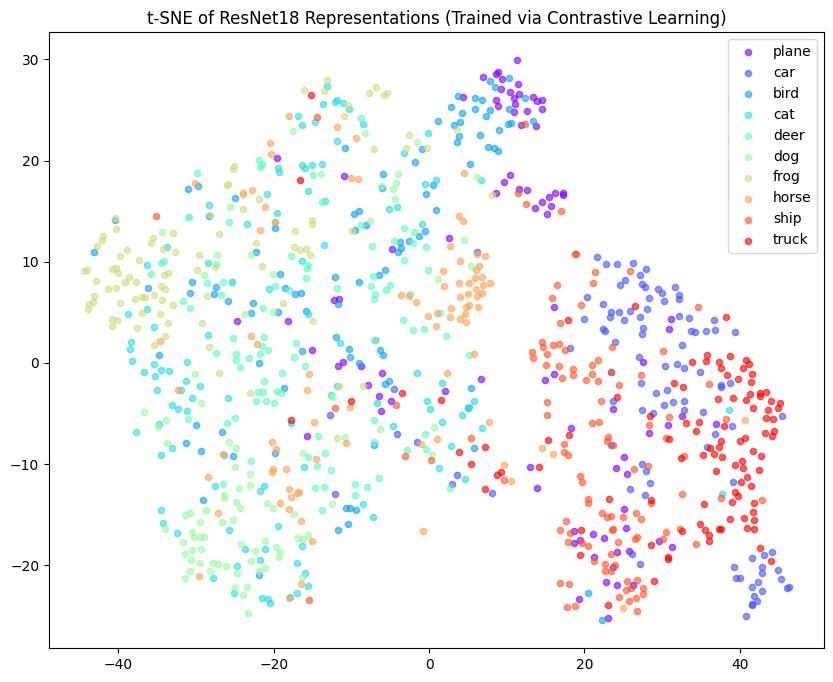

In [8]:
# Load test data (using standard transforms)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
test_dataset = datasets.CIFAR10(root='./data', train=False, transform=test_transform)
# Use a larger batch for better t-SNE visualization
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=True)

# Get a batch of data
images, labels = next(iter(test_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    # We take 'h' (encoder output), NOT 'z' (projection head output)
    h_features, _ = model(images)
    h_features = h_features.cpu().numpy()
    labels = labels.numpy()

print("Running t-SNE visualization... (this might take a minute)")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d = tsne.fit_transform(h_features)

# Plotting
plt.figure(figsize=(10, 8))
CIFAR_LABELS = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
colors = plt.cm.rainbow(np.linspace(0, 1, 10))

for i in range(10):
    indices = labels == i
    plt.scatter(features_2d[indices, 0], features_2d[indices, 1], color=colors[i], label=CIFAR_LABELS[i], alpha=0.6, s=20)

plt.legend()
plt.title("t-SNE of ResNet18 Representations (Trained via Contrastive Learning)")
plt.show()

## 7. Conclusion

Contrastive Learning provides a powerful, general framework for SSL:

1.  **No Pretext Task Design:** Unlike RotNet, we didn't have to invent a task; the task is simply **instance discrimination**.
2.  **High-Quality Features:** The requirement to distinguish subtle differences between augmented views forces the encoder to learn robust, semantically meaningful features.

The clustering seen in the t-SNE plot demonstrates that the model successfully learned to group similar concepts, even though it never saw a single human label. The learned `model.encoder` is now ready to be used as a superior backbone for any downstream supervised task.